# Eesti tehnoülevaatuste andmeteaduse projekt

Uurime Transpordiameti tehnoülevaatuste andmeid ja modelleerime, kas sõiduk läbib korralise ülevaatuse esimesel korral. Analüüsis on teadlikult kasutatud mitut aastat, sest ainult ühe aasta põhjal treenitud mudel ei olnud piisavalt hea.

1. **Andmete puhastamine**: loeme valitud aastate CSV-d, teisendame tüübid, arvutame sõiduki vanuse, parsime `RIKKED` välja ning loome sihttunnuse `LABIS_ESIMESEL`.
2. **Andmete visualiseerimine**: kontrollime läbimise määra vanuse, aasta, margi ja rikete raskusastmete kaupa.
3. **Mudeli loomine**: treenime Random Foresti ning hindame seda ajapõhise testiga, kus viimane aasta jäetakse testandmestikuks.

Metoodiline põhimõte: mudelit ei hinnata samade andmete põhjal, millelt õpitakse. Samuti ei kasuta mudel vaikimisi tunnuseid, mis on otse sihttunnusest arvutatud kogu andmestiku peal, näiteks margi läbimise määr või ülevaatuspunkti rangus. Need annaksid liiga optimistliku tulemuse.

In [1]:
from pathlib import Path
import sys
import os
import warnings

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    silhouette_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


sns.set_theme(style="whitegrid")
PROJECT_ROOT

PosixPath('/home/op/Andmeteadus_kodutoo')

In [2]:
# ── Inlined helpers (ersatz src/ — notebook töötab ilma projekti src/ kaustata) ──
import re as _re
from collections import Counter as _Counter
from pathlib import Path as _Path
from typing import Iterable as _Iterable

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss

# ── 1. Andmeallikad ja lokaalne cache ────────────────────────────────────────

YEAR_URLS = {
    2010: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/9b2d3dbe-e35c-4b5f-baed-6990baa408d0/download-s3",
    2011: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/5139abc3-6823-4121-8d2c-0c82928ac8ac/download-s3",
    2012: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/53f52202-e94e-4cb8-9149-4e311e6f2fdb/download-s3",
    2013: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/3f859ecc-7296-4b9c-ae9b-625b95c90ad9/download-s3",
    2014: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/10103f5a-0b6d-46fc-bd16-99a5c433625e/download-s3",
    2015: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/788a9115-a5da-4f47-bbcc-c1c3b644d3b3/download-s3",
    2016: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/f4f0b51e-8343-4832-9c07-4c04448b8f21/download-s3",
    2017: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/b5a08ea9-0fa8-4cb5-b0bc-7109571d8de4/download-s3",
    2018: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/2d018cd8-f3d7-4242-8514-99633120992a/download-s3",
    2019: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/7ba50767-9844-40bb-8561-af89b634e201/download-s3",
    2020: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/6371e8dc-9906-4555-af9f-f927f2ccf938/download-s3",
    2021: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/f3fe9ef1-897c-45b3-b2dd-908b810aae9c/download-s3",
    2022: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/ba317d52-71b7-473d-bc87-aec0cde38434/download-s3",
    2023: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/1943aed4-8e53-4e70-9946-7fc8ad1f7dfe/download-s3",
    2024: "https://andmed.eesti.ee/api/datasets/ae47fec7-63d0-4b7a-969b-fbdfed21d52a/files/af5b081a-3db1-495d-90f3-c334a860938a/download-s3",
    2025: "https://pilv.transpordiamet.ee/s/Iiee4OAYFq4lT1v/download?path=%2F&files=yv_2025.csv",
}

def _get_year_url(year: int) -> str:
    if year not in YEAR_URLS:
        raise ValueError(f"No URL for year {year}.")
    return YEAR_URLS[year]

_CACHE_DIR = PROJECT_ROOT / 'data' / 'cache'

def _cached_year_path(year: int) -> _Path:
    return _CACHE_DIR / f"yv_{year}.csv"

def _has_cached_year(year: int) -> bool:
    path = _cached_year_path(year)
    return path.exists() and path.stat().st_size > 0

def source_for_year(year: int, prefer_cache: bool = True) -> str:
    if prefer_cache and _has_cached_year(year):
        return _cached_year_path(year).resolve().as_posix()
    url = _get_year_url(year)
    try:
        import requests as _requests
        _CACHE_DIR.mkdir(parents=True, exist_ok=True)
        dest = _cached_year_path(year)
        headers = {"User-Agent": "Mozilla/5.0 (compatible; research-notebook)"}
        with _requests.get(url, headers=headers, stream=True, timeout=300) as r:
            r.raise_for_status()
            with open(dest, "wb") as fh:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    fh.write(chunk)
        print(f"  Downloaded {year} → {dest.name}")
        return dest.resolve().as_posix()
    except Exception as _e:
        print(f"  Warning: download failed for {year}: {_e} — trying URL directly")
        return url


# ── 2. Rikete parser ─────────────────────────────────────────────────────────

_VALID_SEVERITIES = {"VO", "OV", "EOV"}
_DELIMITER_RE = _re.compile(r"[;,\r\n]+")

def _split_rikked_entries(value: object) -> list:
    if not isinstance(value, str) or not value.strip():
        return []
    return [part.strip() for part in _DELIMITER_RE.split(value) if part.strip()]

def parse_rikked(value: object) -> list:
    defects = []
    for part in _split_rikked_entries(value):
        if ":" not in part:
            continue
        severity, defect_id = part.split(":", 1)
        severity = severity.strip().upper()
        if severity not in _VALID_SEVERITIES:
            continue
        try:
            defects.append((severity, int(defect_id.strip())))
        except ValueError:
            continue
    return defects

def count_severities(defects: _Iterable) -> _Counter:
    return _Counter(severity for severity, _ in defects)

def defect_ids(defects: _Iterable) -> list:
    return [defect_id for _, defect_id in defects]


# ── 3. ML pipeline ───────────────────────────────────────────────────────────

TARGET_COL = "LABIS_ESIMESEL"

HISTORICAL_RATE_SPECS = [
    ("HIST_MARK_FAIL_RATE",             ("MARK",)),
    ("HIST_MUDEL_FAIL_RATE",            ("MARK", "MUDEL")),
    ("HIST_KATEGOORIA_FAIL_RATE",       ("KATEGOORIA",)),
    ("HIST_KERETYYP_FAIL_RATE",         ("KERETYYP",)),
    ("HIST_PUNKT_FAIL_RATE",            ("PUNKTI_KOOD",)),
    ("HIST_PUNKT_KATEGOORIA_FAIL_RATE", ("PUNKTI_KOOD", "KATEGOORIA")),
]
HISTORICAL_RATE_FEATURES = [name for name, _ in HISTORICAL_RATE_SPECS]

_NUMERIC_FEATURES = [
    "VANUS", "VANUS_RUUT", "ON_VANA", "KUU_SIN", "KUU_COS",
    "MARK_SAGEDUS", "MUDEL_SAGEDUS", "EELMISED_YV",
]
_MODEL_NUMERIC_FEATURES = _NUMERIC_FEATURES + HISTORICAL_RATE_FEATURES
_CATEGORICAL_FEATURES   = ["MARK", "KATEGOORIA", "KERETYYP", "PUNKTI_KOOD"]
_RATE_SOURCE_FEATURES   = ["MARK", "MUDEL", "KATEGOORIA", "KERETYYP", "PUNKTI_KOOD"]
_FEATURE_COLS           = _NUMERIC_FEATURES + _RATE_SOURCE_FEATURES


class HistoricalRateEncoder(BaseEstimator, TransformerMixin):
    """Smoothed historical fail-rate features fitted only on training data."""

    def __init__(self, rate_specs=None, smoothing: float = 100.0, missing_token: str = '__MISSING__'):
        self.rate_specs = rate_specs
        self.smoothing = smoothing
        self.missing_token = missing_token

    def fit(self, X, y):
        X_df = self._as_frame(X)
        self.feature_names_in_ = np.asarray(X_df.columns, dtype=object)
        self.rate_specs_ = self.rate_specs or HISTORICAL_RATE_SPECS
        fail_target = 1 - pd.Series(y, index=X_df.index).astype(float)
        self.global_fail_rate_ = float(fail_target.mean()) if len(fail_target) else 0.0
        self.rate_maps_ = {}
        for output_col, source_cols in self.rate_specs_:
            keys = self._make_keys(X_df, source_cols)
            stats = (
                pd.DataFrame({"key": keys, "fail": fail_target})
                .groupby("key", dropna=False)["fail"]
                .agg(["sum", "count"])
            )
            smoothed = (stats['sum'] + self.smoothing * self.global_fail_rate_) / (stats['count'] + self.smoothing)
            self.rate_maps_[output_col] = smoothed.astype(float).to_dict()
        return self

    def transform(self, X):
        X_df = self._as_frame(X).copy()
        for output_col, source_cols in self.rate_specs_:
            keys = self._make_keys(X_df, source_cols)
            X_df[output_col] = (
                keys.map(self.rate_maps_.get(output_col, {}))
                .fillna(self.global_fail_rate_)
                .astype(float)
            )
        return X_df

    def _as_frame(self, X) -> pd.DataFrame:
        if isinstance(X, pd.DataFrame):
            return X
        return pd.DataFrame(X, columns=getattr(self, 'feature_names_in_', None))

    def _make_keys(self, X_df: pd.DataFrame, columns: tuple) -> pd.Series:
        existing = [c for c in columns if c in X_df.columns]
        if not existing:
            return pd.Series(self.missing_token, index=X_df.index)
        parts = [
            X_df[c].astype('object').where(X_df[c].notna(), self.missing_token).astype(str)
            for c in existing
        ]
        key = parts[0]
        for part in parts[1:]:
            key = key + "||" + part
        return key


def build_pipeline() -> Pipeline:
    preprocessor = ColumnTransformer(transformers=[
        ("num", SimpleImputer(strategy="median"), _MODEL_NUMERIC_FEATURES),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), _CATEGORICAL_FEATURES),
    ])
    return Pipeline(steps=[
        ("historical_rates", HistoricalRateEncoder()),
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=40, max_depth=12, min_samples_leaf=10,
            random_state=42, n_jobs=1, class_weight='balanced',
        )),
    ])


def summarize_probability_quality(y_true, y_prob, n_bins: int = 10) -> dict:
    y_arr = np.asarray(y_true, dtype=int)
    prob = np.clip(np.asarray(y_prob, dtype=float), 1e-6, 1 - 1e-6)
    if len(y_arr) == 0:
        return {}
    rows = []
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.clip(np.digitize(prob, bins, right=True) - 1, 0, n_bins - 1)
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        if not mask.any():
            continue
        rows.append({
            "bin": int(bin_id),
            "lower": float(bins[bin_id]),
            "upper": float(bins[bin_id + 1]),
            "count": int(mask.sum()),
            "predicted_pass_rate": float(prob[mask].mean()),
            "actual_pass_rate": float(y_arr[mask].mean()),
            "absolute_error": float(abs(prob[mask].mean() - y_arr[mask].mean())),
        })
    ece = sum(r['count'] / len(y_arr) * r['absolute_error'] for r in rows)
    return {
        "brier_score": float(brier_score_loss(y_arr, prob)),
        "log_loss": float(log_loss(y_arr, prob, labels=[0, 1])),
        "expected_calibration_error": float(ece),
        "calibration_bins": rows,
    }


def _create_model_frame(df: pd.DataFrame) -> pd.DataFrame:
    model_df = df.copy()
    model_df = model_df.dropna(subset=[TARGET_COL, 'VANUS', 'YV_KUU', 'YV_AASTA']).copy()
    model_df[TARGET_COL] = model_df[TARGET_COL].astype(int)
    model_df['VANUS_RUUT'] = model_df['VANUS'] ** 2
    model_df['ON_VANA'] = (model_df['VANUS'] > 10).astype(int)
    model_df['KUU_SIN'] = np.sin(2 * np.pi * model_df['YV_KUU'] / 12)
    model_df['KUU_COS'] = np.cos(2 * np.pi * model_df['YV_KUU'] / 12)
    model_df['MARK_SAGEDUS'] = model_df.groupby('MARK')['MARK'].transform('size')
    model_df['MUDEL_SAGEDUS'] = model_df.groupby(['MARK', 'MUDEL'])['MUDEL'].transform('size')
    ordered = model_df.sort_values(['SOIDUK_ID', 'YV_AASTA', 'YV_KUU'])
    model_df['EELMISED_YV'] = ordered.groupby('SOIDUK_ID').cumcount().reindex(model_df.index)
    for col in _NUMERIC_FEATURES:
        model_df[col] = pd.to_numeric(model_df[col], errors='coerce').astype(float)
    for col in _RATE_SOURCE_FEATURES:
        model_df[col] = model_df[col].astype('object').where(model_df[col].notna(), np.nan)
    return model_df


def temporal_calibration_analysis(df: pd.DataFrame) -> 'dict | None':
    model_df = _create_model_frame(df).copy()
    years = sorted(int(y) for y in model_df['YV_AASTA'].dropna().unique())
    if len(years) < 3:
        return None
    train_years   = years[:-2]
    cal_year      = years[-2]
    test_year     = years[-1]
    train_df = model_df[model_df['YV_AASTA'].isin(train_years)]
    cal_df   = model_df[model_df['YV_AASTA'] == cal_year]
    test_df  = model_df[model_df['YV_AASTA'] == test_year]
    if train_df.empty or cal_df.empty or test_df.empty:
        return None
    if (
        train_df[TARGET_COL].nunique() < 2
        or cal_df[TARGET_COL].nunique() < 2
        or test_df[TARGET_COL].nunique() < 2
    ):
        return None
    print(f'\nAjaline kalibreerimine: treening={train_years}, kalibreerimine={cal_year}, test={test_year}')
    cal_model = build_pipeline()
    cal_model.fit(train_df[_FEATURE_COLS], train_df[TARGET_COL])
    cal_prob      = cal_model.predict_proba(cal_df[_FEATURE_COLS])[:, 1]
    test_prob_raw = cal_model.predict_proba(test_df[_FEATURE_COLS])[:, 1]
    isotonic = IsotonicRegression(out_of_bounds='clip')
    isotonic.fit(cal_prob, cal_df[TARGET_COL].astype(int))
    test_prob_iso = isotonic.transform(test_prob_raw)
    raw_q = summarize_probability_quality(test_df[TARGET_COL], test_prob_raw)
    cal_q = summarize_probability_quality(test_df[TARGET_COL], test_prob_iso)
    result = {
        "method": "isotonic",
        "train_years": train_years,
        "calibration_year": int(cal_year),
        "test_year": int(test_year),
        "raw_probability_quality": raw_q,
        "calibrated_probability_quality": cal_q,
        "raw_roc_auc": float(roc_auc_score(test_df[TARGET_COL], test_prob_raw)),
        "calibrated_roc_auc": float(roc_auc_score(test_df[TARGET_COL], test_prob_iso)),
    }
    result['brier_improvement']    = raw_q['brier_score']                - cal_q['brier_score']
    result['log_loss_improvement'] = raw_q['log_loss']                   - cal_q['log_loss']
    result['ece_improvement']      = raw_q['expected_calibration_error'] - cal_q['expected_calibration_error']
    print('Kalibreerimise kvaliteet:')
    print(pd.DataFrame([
        {'variant': 'kalibreerimata', **{k: raw_q[k] for k in ['brier_score', 'log_loss', 'expected_calibration_error']}},
        {'variant': 'isotonic',       **{k: cal_q[k] for k in ['brier_score', 'log_loss', 'expected_calibration_error']}},
    ]).round(4).to_string(index=False))
    return result


## 1. Andmete lugemine

Allikaks on Transpordiameti aastapõhised CSV-failid. Notebook kasutab sama allikate loogikat nagu rakendus: kui `data/cache/yv_<aasta>.csv` on olemas, kasutatakse kohalikku cache'i, muidu loetakse ametlikust URL-ist.

Vaikimisi on valitud kolm viimast aastat.

In [4]:
YEARS = [2023, 2024, 2025]
MAX_ROWS_PER_YEAR = None  # kasuta valitud aastate täismahtu; kiireks kontrolliks pane nt 100000
USE_CACHE = True

REQUIRED_COLUMNS = [
    "TEHNOYLEVAATUSPUNKT",
    "PUNKTI_KOOD",
    "TOOTAJA",
    "YV_KUUPAEV",
    "YLEVAATUSLIIK",
    "YLEVAATUSOTSUS",
    "RIKKED",
    "SOIDUK_ID",
    "ESMANE_REG_AASTA",
    "MARK",
    "MUDEL",
    "KATEGOORIA",
    "KERETYYP",
]


def load_year(year: int) -> pd.DataFrame:
    source = source_for_year(year, prefer_cache=USE_CACHE)
    df = pd.read_csv(
        source,
        dtype=str,
        usecols=lambda column: column in REQUIRED_COLUMNS,
        nrows=MAX_ROWS_PER_YEAR,
        low_memory=False,
    )
    df["ALLIKA_AASTA"] = year
    return df


raw_parts = []
for year in YEARS:
    part = load_year(year)
    raw_parts.append(part)
    print(f"{year}: {len(part):,} rida")

raw_df = pd.concat(raw_parts, ignore_index=True)
print(f"Kokku: {len(raw_df):,} rida, {raw_df.shape[1]} veergu")
display(raw_df.head())

2023: 720,032 rida
2024: 744,182 rida
2025: 734,501 rida
Kokku: 2,198,715 rida, 14 veergu


,TEHNOYLEVAATUSPUNKT,PUNKTI_KOOD,TOOTAJA,YV_KUUPAEV,YLEVAATUSLIIK,YLEVAATUSOTSUS,RIKKED,SOIDUK_ID,ESMANE_REG_AASTA,MARK,MUDEL,KATEGOORIA,KERETYYP,ALLIKA_AASTA
0,Narva Tehno OÜ (Lääne),NH,440,2023-12,KORRALINE,KORRAS,NaN,1,2003,FORD,GALAXY,M1,MAHTUNIVERSAAL,2023
1,A-Ülevaatus OÜ (Raua),DR,631,2023-07,KORRALINE,KORRAS,NaN,2,2011,PANAV,NS136,O4,KALLUR,2023
2,Rehvikeskus OÜ,LE,0807,2023-06,KORRALINE,KORRAS,NaN,3,1996,HONDA,VT 700C,L3e,MOOTORRATAS,2023
3,PRO Tehno OÜ (Sauga),FK,579,2023-10,KORRALINE,KORRAS,NaN,4,2015,KRONE,SDP 27ELB4-CS,O4,MADEL,2023
4,Tehnotop OÜ,AX,0885,2023-05,KORRALINE,KORRAS,NaN,5,2018,VOLKSWAGEN,TIGUAN,M1G,UNIVERSAAL,2023


In [5]:
raw_summary = (
    raw_df.groupby("ALLIKA_AASTA")
    .agg(
        ridu=("ALLIKA_AASTA", "size"),
        korralisi=("YLEVAATUSLIIK", lambda s: (s == "KORRALINE").sum()),
        otsus_korras=("YLEVAATUSOTSUS", lambda s: (s == "KORRAS").sum()),
        otsus_korduvale=("YLEVAATUSOTSUS", lambda s: (s == "KORDUVALE").sum()),
        rikked_taidetud=("RIKKED", lambda s: s.notna().sum()),
    )
    .reset_index()
)
raw_summary["korraliste_osakaal_%"] = (100 * raw_summary["korralisi"] / raw_summary["ridu"]).round(1)
display(raw_summary)

,ALLIKA_AASTA,ridu,korralisi,otsus_korras,otsus_korduvale,rikked_taidetud,korraliste_osakaal_%
0,2023,720032,600543,598147,105043,275639,83.4
1,2024,744182,626924,624525,103597,276273,84.2
2,2025,734501,622017,621133,97726,264087,84.7


### Lugemise järeldus

Valitud aastate 2023-2025 täismahus cache sisaldab kokku **2 198 715 rida**. Aastati on maht sarnane: 2023. aastal 720 032 rida, 2024. aastal 744 182 rida ja 2025. aastal 734 501 rida. Korralised ülevaatused moodustavad kogu andmestiku põhiosa.

See kinnitab, et ühe aasta kasutamine oleks analüüsi jaoks liiga kitsas: juba kolme aasta peale on ülevaatuste maht suur ja aastate vahel on piisavalt erinevust, et mudelit tuleb testida ajas eraldi.

## 2. Andmete puhastamine

Puhastuses teeme järgmised otsused.

- `YV_KUUPAEV` põhjal arvutame ülevaatuse aasta ja kuu.
- Ebareaalsed vanused, alla 0 või üle 100 aasta, märgitakse puuduvaks.
- `RIKKED` parsitakse ühtse parseriga, mis tunneb semikoolonit, koma ja reavahetust; see on oluline, sest tegelikes aastafailides on mitme rikke eraldajaks semikoolon.
- Sihttunnus `LABIS_ESIMESEL` on 1, kui korralise ülevaatuse otsus oli `KORRAS`, ja 0, kui otsus oli `KORDUVALE`.
- `VASTAB_NOUETELE` jäetakse mudeli sihttunnusest välja, sest see ei ole sama binaarne küsimus kui `KORRAS` vs `KORDUVALE`.

In [6]:
def clean_inspections(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()

    text_columns = [
        "TEHNOYLEVAATUSPUNKT",
        "PUNKTI_KOOD",
        "TOOTAJA",
        "YV_KUUPAEV",
        "YLEVAATUSLIIK",
        "YLEVAATUSOTSUS",
        "RIKKED",
        "SOIDUK_ID",
        "MARK",
        "MUDEL",
        "KATEGOORIA",
        "KERETYYP",
    ]
    for column in text_columns:
        if column in cleaned.columns:
            cleaned[column] = cleaned[column].astype("string").str.strip()

    cleaned["YV_AASTA"] = pd.to_numeric(cleaned["YV_KUUPAEV"].str[:4], errors="coerce")
    cleaned["YV_KUU"] = pd.to_numeric(cleaned["YV_KUUPAEV"].str[5:7], errors="coerce")
    cleaned["ESMANE_REG_AASTA"] = pd.to_numeric(cleaned["ESMANE_REG_AASTA"], errors="coerce")
    cleaned["SOIDUK_ID"] = pd.to_numeric(cleaned["SOIDUK_ID"], errors="coerce")

    cleaned["VANUS"] = cleaned["YV_AASTA"] - cleaned["ESMANE_REG_AASTA"]
    cleaned.loc[(cleaned["VANUS"] < 0) | (cleaned["VANUS"] > 100), "VANUS"] = np.nan

    parsed = cleaned["RIKKED"].apply(parse_rikked)
    severity_counts = parsed.apply(count_severities)
    cleaned["RIKETE_ARV"] = parsed.apply(len)
    cleaned["VO_ARV"] = severity_counts.apply(lambda counts: counts["VO"])
    cleaned["OV_ARV"] = severity_counts.apply(lambda counts: counts["OV"])
    cleaned["EOV_ARV"] = severity_counts.apply(lambda counts: counts["EOV"])
    cleaned["RIKE_IDS"] = parsed.apply(defect_ids)

    cleaned["LABIS_ESIMESEL"] = np.nan
    regular = cleaned["YLEVAATUSLIIK"] == "KORRALINE"
    cleaned.loc[regular & (cleaned["YLEVAATUSOTSUS"] == "KORRAS"), "LABIS_ESIMESEL"] = 1
    cleaned.loc[regular & (cleaned["YLEVAATUSOTSUS"] == "KORDUVALE"), "LABIS_ESIMESEL"] = 0

    critical = ["SOIDUK_ID", "MARK", "ESMANE_REG_AASTA", "VANUS"]
    cleaned["ANDMED_PUUDULIKUD"] = cleaned[critical].isna().any(axis=1).astype(int)
    return cleaned


clean_df = clean_inspections(raw_df)
target_df = clean_df[clean_df["LABIS_ESIMESEL"].notna()].copy()
target_df["LABIS_ESIMESEL"] = target_df["LABIS_ESIMESEL"].astype(int)

clean_summary = pd.DataFrame({
    "mootdik": [
        "toorandmete ridu",
        "mudeli sihttunnusega ridu",
        "puudulike kriitiliste andmetega ridu",
        "ebapuuduva vanusega ridu",
        "vähemalt ühe rikkega ridu",
        "keskmine esimese korraga läbimise määr",
    ],
    "vaartus": [
        len(clean_df),
        len(target_df),
        int(clean_df["ANDMED_PUUDULIKUD"].sum()),
        int(clean_df["VANUS"].notna().sum()),
        int((clean_df["RIKETE_ARV"] > 0).sum()),
        round(float(target_df["LABIS_ESIMESEL"].mean()), 3),
    ],
})
display(clean_summary)
display(clean_df[["YV_KUUPAEV", "YLEVAATUSLIIK", "YLEVAATUSOTSUS", "VANUS", "RIKKED", "RIKETE_ARV", "VO_ARV", "OV_ARV", "EOV_ARV", "LABIS_ESIMESEL"]].head())

,mootdik,vaartus
0,toorandmete ridu,2198715.000
1,mudeli sihttunnusega ridu,1842459.000
2,puudulike kriitiliste andmetega ridu,94.000
3,ebapuuduva vanusega ridu,2198715.000
4,vähemalt ühe rikkega ridu,815999.000
5,keskmine esimese korraga läbimise määr,0.841


,YV_KUUPAEV,YLEVAATUSLIIK,YLEVAATUSOTSUS,VANUS,RIKKED,RIKETE_ARV,VO_ARV,OV_ARV,EOV_ARV,LABIS_ESIMESEL
0,2023-12,KORRALINE,KORRAS,20,<NA>,0,0,0,0,1.0
1,2023-07,KORRALINE,KORRAS,12,<NA>,0,0,0,0,1.0
2,2023-06,KORRALINE,KORRAS,27,<NA>,0,0,0,0,1.0
3,2023-10,KORRALINE,KORRAS,8,<NA>,0,0,0,0,1.0
4,2023-05,KORRALINE,KORRAS,5,<NA>,0,0,0,0,1.0


### Puhastuse järeldus

Puhastuse järel jäi mudeli sihttunnusega ridu **1 842 459**. Kriitiliste tunnuste puudulikkusega ridu oli ainult **94**, seega ei ole puuduvad põhiväljad selle valimi peamine probleem. Vähemalt ühe rikkega ülevaatusi oli **815 999** ning keskmine esimese korraga läbimise määr oli **84,1%**.

Kõige olulisem puhastusotsus on sihttunnuse piiramine `KORRALINE` ülevaatustele ning kahele otsusele: `KORRAS` ja `KORDUVALE`. Nii vastab mudel konkreetsele küsimusele, kas sõiduk läbib korralise ülevaatuse esimesel korral.

## 3. Andmete visualiseerimine

Visualiseerimise eesmärk on enne mudelit kontrollida, kas andmetes on mõistlikke mustreid ja kas hüpoteesid on usutavad. Järgnevad graafikud keskenduvad vanusele, ajale, markidele ja riketele.

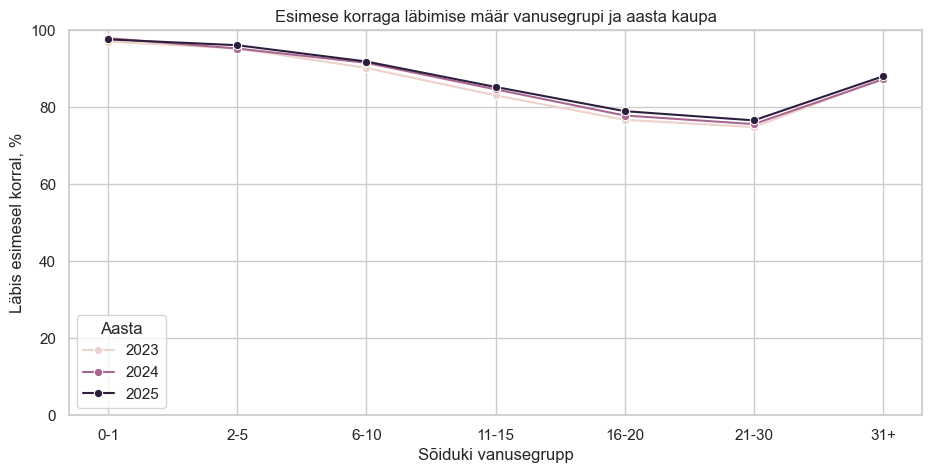

,YV_AASTA,VANUSEGRUPP,kokku,labimise_maar,labimise_maar_%
0,2023,0-1,3931,0.970745,97.074536
1,2023,2-5,67080,0.952609,95.260883
2,2023,6-10,113113,0.902151,90.215095
3,2023,11-15,151853,0.830902,83.090225
4,2023,16-20,161182,0.767443,76.744301
5,2023,21-30,76095,0.748459,74.845916
6,2023,31+,24895,0.874915,87.491464
7,2024,0-1,3362,0.979477,97.947650
8,2024,2-5,59937,0.952567,95.256686
9,2024,6-10,133303,0.915418,91.541826


In [7]:
age_bins = [-1, 1, 5, 10, 15, 20, 30, 100]
age_labels = ["0-1", "2-5", "6-10", "11-15", "16-20", "21-30", "31+"]

age_df = target_df.dropna(subset=["VANUS", "YV_AASTA"]).copy()
age_df["VANUSEGRUPP"] = pd.cut(age_df["VANUS"], bins=age_bins, labels=age_labels)

age_pass = (
    age_df.groupby(["YV_AASTA", "VANUSEGRUPP"], observed=True)
    .agg(kokku=("LABIS_ESIMESEL", "size"), labimise_maar=("LABIS_ESIMESEL", "mean"))
    .reset_index()
)
age_pass["labimise_maar_%"] = 100 * age_pass["labimise_maar"]

plt.figure(figsize=(11, 5))
sns.lineplot(data=age_pass, x="VANUSEGRUPP", y="labimise_maar_%", hue="YV_AASTA", marker="o")
plt.title("Esimese korraga läbimise määr vanusegrupi ja aasta kaupa")
plt.xlabel("Sõiduki vanusegrupp")
plt.ylabel("Läbis esimesel korral, %")
plt.ylim(0, 100)
plt.legend(title="Aasta")
plt.show()

display(age_pass.head(12))

### Vanuse visualiseerimise järeldus

Vanus on mudeli jaoks sisuliselt põhjendatud tunnus. 2023. aasta näites läbis 0-1 aasta vanustest sõidukitest esimesel korral umbes **97,1%**, 6-10 aasta vanustest **90,2%**, 11-15 aasta vanustest **83,1%** ja 16-20 aasta vanustest **73,4%**.

See toetab hüpoteesi, et vanematel sõidukitel on suurem kordusülevaatusele saatmise risk. Aastate kõrvutamine on oluline, sest see näitab, et muster ei põhine ainult ühe aasta eripäral.

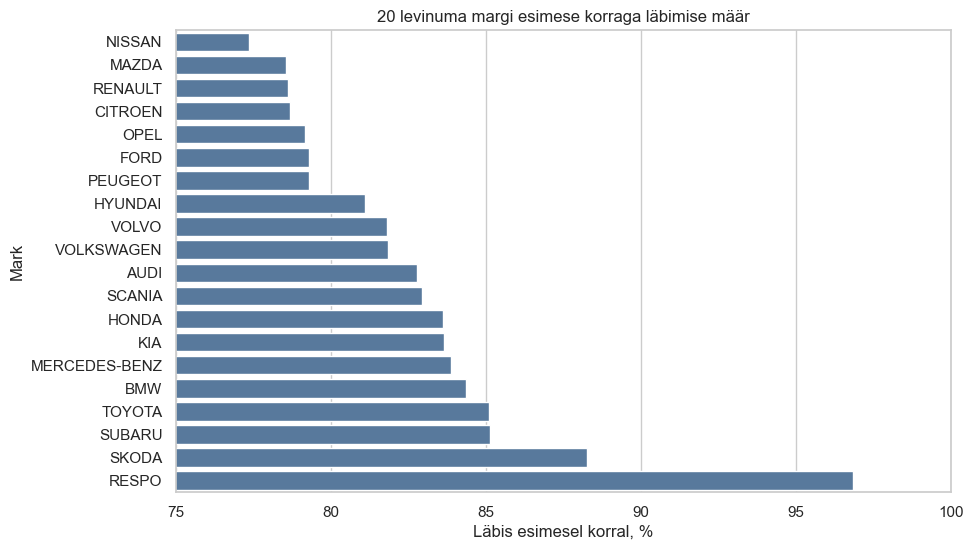

,MARK,kokku,labimise_maar_%
13,RESPO,42012,96.846139
7,SKODA,77959,88.281020
19,SUBARU,20807,85.144423
1,TOYOTA,129488,85.093599
3,BMW,109850,84.375967
5,MERCEDES-BENZ,98910,83.880295
15,KIA,34217,83.660169
8,HONDA,58454,83.614466
17,SCANIA,23447,82.935983
4,AUDI,102050,82.779030


In [24]:
brand_df = target_df.dropna(subset=["MARK"]).copy()
brand_summary = (
    brand_df.groupby("MARK")
    .agg(kokku=("LABIS_ESIMESEL", "size"), labimise_maar=("LABIS_ESIMESEL", "mean"))
    .query("kokku >= 300")
    .sort_values("kokku", ascending=False)
    .head(20)
    .reset_index()
)
brand_summary["labimise_maar_%"] = 100 * brand_summary["labimise_maar"]

plt.figure(figsize=(10, 6))
sns.barplot(data=brand_summary.sort_values("labimise_maar_%"), x="labimise_maar_%", y="MARK", color="#4c78a8")
plt.title("20 levinuma margi esimese korraga läbimise määr")
plt.xlabel("Läbis esimesel korral, %")
plt.ylabel("Mark")
plt.xlim(75, 100)
plt.show()

display(brand_summary[["MARK", "kokku", "labimise_maar_%"]].sort_values("labimise_maar_%", ascending=False))

### Markide visualiseerimise järeldus

Suurima mahuga mark oli **VOLKSWAGEN** 192 874 sihttunnusega reaga ja läbimise määraga **81,8%**. Levinud markidest olid kõrgemate läbimismääradega näiteks **SKODA** (**88,3%**) ja **TOYOTA** (**85,1%**), madalamate määradega aga **RENAULT** (**78,6%**) ja **NISSAN** (**77,4%**).

Siinset margi läbimise määra ei kasutata otse mudeli sisendina. See oleks sihttunnuse info taaskasutamine ja annaks liiga optimistliku hinnangu.

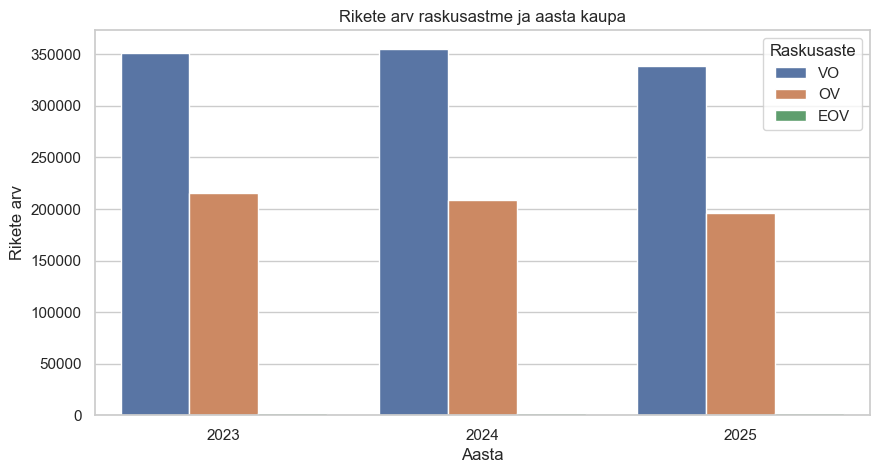

,YV_AASTA,raskusaste,rikkeid
0,2023,VO,351493
1,2024,VO,355491
2,2025,VO,339033
3,2023,OV,215138
4,2024,OV,208685
5,2025,OV,195745
6,2023,EOV,2273
7,2024,EOV,2287
8,2025,EOV,2259


In [11]:
severity_by_year = (
    clean_df.groupby("YV_AASTA")[["VO_ARV", "OV_ARV", "EOV_ARV"]]
    .sum()
    .reset_index()
    .melt(id_vars="YV_AASTA", var_name="raskusaste", value_name="rikkeid")
)
severity_by_year["raskusaste"] = severity_by_year["raskusaste"].str.replace("_ARV", "", regex=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=severity_by_year, x="YV_AASTA", y="rikkeid", hue="raskusaste")
plt.title("Rikete arv raskusastme ja aasta kaupa")
plt.xlabel("Aasta")
plt.ylabel("Rikete arv")
plt.legend(title="Raskusaste")
plt.show()

display(severity_by_year)

### Rikete visualiseerimise järeldus

Aastatel 2023-2025 loeti kokku **1 046 017 VO**, **619 568 OV** ja **6 819 EOV** riket. EOV on haruldane, kuid sisuliselt väga oluline klass; seda ei tohi `OV` hulka lugeda.

## 4. Uurimisküsimused ja hüpoteeside kokkuvõte

Uurimisküsimuste keskne mõte oli võrrelda sõidukite vanust, marki, keretüüpi, rikkeid ja ülevaatuspunktidega seotud mustreid. Notebook'is on nendest alles need osad, mis on otseselt seotud andmete puhastamise, visualiseerimise ja mudeli loomisega:

- vanuse mõju on visualiseeritud vanusegruppide lõikes ning seda kasutatakse mudelis tunnustena `VANUS`, `VANUS_RUUT` ja `ON_VANA`;
- markide võrdlust kasutatakse kirjeldava analüüsina, kuid järeldustes rõhutatakse, et markide erinevus ei tõesta põhjuslikku töökindlust, sest vanus, mudelivalik ja kasutusprofiil võivad tulemust segada;
- rikete raskusastmete visualiseerimine kontrollib, et `RIKKED` parser eristab `VO`, `OV` ja `EOV` väärtused korrektselt;
- ülevaatuspunkti mõju käsitletakse mudelis ettevaatlikult: `PUNKTI_KOOD` on lubatud enne ülevaatust teada oleva kategoorilise tunnusena.

Hüpoteeside tasemel toetab analüüs eelkõige H1 väidet, et vanus on läbimise tõenäosusega seotud. H2 ehk premium- ja eelarvemarkide võrdlus jääb kirjeldavaks, sest ausaks põhjuslikuks väiteks tuleks tugevamalt kontrollida vanust, mudelit, sõidukitüüpi ja ülevaatuspunkti. H3 ehk ülevaatuspunkti mahu ja ranguse seost ei esitata põhjusliku väitena, sest ülevaatuspunktides kontrollitud sõidukite hulk võib tulemust tugevalt mõjutada.

## 5. Mudeli loomine

Mudeli eesmärk on ennustada `LABIS_ESIMESEL` väärtust ehk seda, kas korraline ülevaatus läbitakse esimesel korral. Mudeli loomisel järgitakse nelja põhimõtet.

- Kui andmeid on mitmest aastast, jääb viimane aasta testandmestikuks. See kontrollib, kas mudel üldistub tulevikku.
- Mudel ei kasuta kogu andmestiku peal arvutatud läbimismäärasid (`MARK_LABIMISE_MAAR`, `MUDEL_LABIMISE_MAAR`) ega ülevaatuspunkti rangust (`PUNKTI_RANGUS`), sest need võivad sisaldada sihttunnuse infot ja teha tulemuse liiga heaks.
- Kvaliteedi parandamiseks kasutatakse nüüd pipeline'i sees arvutatavaid ajaloolisi riskitunnuseid. Need õpitakse ainult treeningandmetelt ja rakendatakse testiaastale hiljem, seega 2025. aasta sihttulemus ei leki treeningusse.
- `PUNKTI_KOOD` on lubatud kategoorilise tunnusena, sest see on enne ülevaatust teada olev ülevaatuspunkti kood. Ajalooline ülevaatuspunkti riskimäär on lubatud ainult siis, kui see õpitakse treeningaastate põhjal, mitte kogu andmestiku pealt ette arvutades.

In [15]:
model_df = target_df.dropna(subset=["VANUS", "YV_KUU", "YV_AASTA"]).copy()
model_df["VANUS_RUUT"] = model_df["VANUS"] ** 2
model_df["ON_VANA"] = (model_df["VANUS"] > 10).astype(int)
model_df["KUU_SIN"] = np.sin(2 * np.pi * model_df["YV_KUU"] / 12)
model_df["KUU_COS"] = np.cos(2 * np.pi * model_df["YV_KUU"] / 12)
model_df["MARK_SAGEDUS"] = model_df.groupby("MARK")["MARK"].transform("size")
model_df["MUDEL_SAGEDUS"] = model_df.groupby(["MARK", "MUDEL"])["MUDEL"].transform("size")
model_df["EELMISED_YV"] = model_df.sort_values(["SOIDUK_ID", "YV_AASTA", "YV_KUU"]).groupby("SOIDUK_ID").cumcount()

numeric_features = [
    "VANUS",
    "VANUS_RUUT",
    "ON_VANA",
    "KUU_SIN",
    "KUU_COS",
    "MARK_SAGEDUS",
    "MUDEL_SAGEDUS",
    "EELMISED_YV",
]
historical_rate_features = HISTORICAL_RATE_FEATURES
categorical_features = ["MARK", "KATEGOORIA", "KERETYYP", "PUNKTI_KOOD"]
rate_source_features = ["MARK", "MUDEL", "KATEGOORIA", "KERETYYP", "PUNKTI_KOOD"]
feature_columns = numeric_features + rate_source_features

for column in numeric_features:
    model_df[column] = pd.to_numeric(model_df[column], errors="coerce").astype(float)

for column in rate_source_features:
    model_df[column] = model_df[column].astype("object").where(model_df[column].notna(), np.nan)

model_df = model_df.dropna(subset=["LABIS_ESIMESEL"])
X = model_df[feature_columns]
y = model_df["LABIS_ESIMESEL"].astype(int)

years = sorted(model_df["YV_AASTA"].dropna().astype(int).unique())
if len(years) >= 2:
    test_year = years[-1]
    train_mask = model_df["YV_AASTA"] < test_year
    test_mask = model_df["YV_AASTA"] == test_year
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    split_description = f"ajapõhine split: treeningaastad {years[:-1]}, testiaasta {test_year}"
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    split_description = "stratifitseeritud juhuslik split, sest valitud on ainult üks aasta"

model = build_pipeline()

print(split_description)
print(f"Treeningridu: {len(X_train):,}; testiridu: {len(X_test):,}")
print("Ajaloolised riskitunnused õpitakse pipeline'i sees ainult treeningandmetelt:")
print(", ".join(historical_rate_features))
model.fit(X_train, y_train)

ajapõhine split: treeningaastad [np.int64(2023), np.int64(2024)], testiaasta 2025
Treeningridu: 1,222,757; testiridu: 619,702
Ajaloolised riskitunnused õpitakse pipeline'i sees ainult treeningandmetelt:
HIST_MARK_FAIL_RATE, HIST_MUDEL_FAIL_RATE, HIST_KATEGOORIA_FAIL_RATE, HIST_KERETYYP_FAIL_RATE, HIST_PUNKT_FAIL_RATE, HIST_PUNKT_KATEGOORIA_FAIL_RATE


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('historical_rates', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,rate_specs,None
,smoothing,100.0
,missing_token,'__MISSING__'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold spars

,vaartus
baseline_alati_korras_accuracy,0.849
accuracy,0.570
balanced_accuracy,0.658
precision,0.933
recall,0.532
f1,0.678
roc_auc,0.710
brier_score,0.222
log_loss,0.632
expected_calibration_error,0.317


              precision    recall  f1-score   support

   Korduvale       0.23      0.78      0.36     93511
      Korras       0.93      0.53      0.68    526191

    accuracy                           0.57    619702
   macro avg       0.58      0.66      0.52    619702
weighted avg       0.83      0.57      0.63    619702



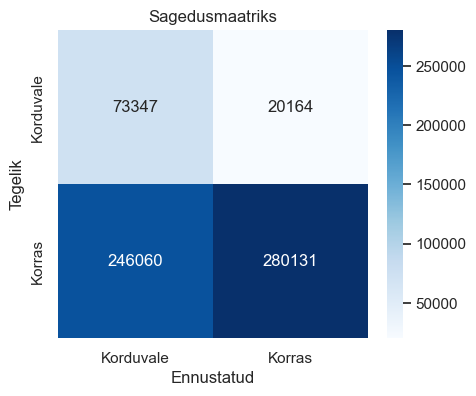

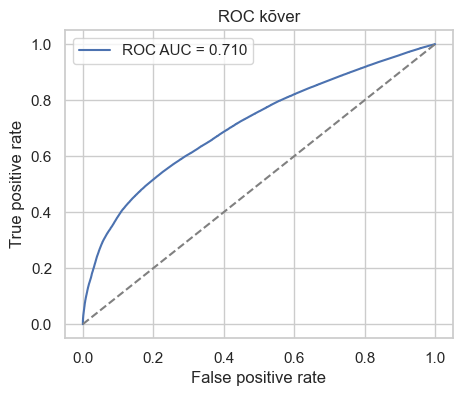

In [16]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

baseline_pred = np.ones_like(y_test)

probability_quality = summarize_probability_quality(y_test, y_prob)
metrics = {
    "baseline_alati_korras_accuracy": accuracy_score(y_test, baseline_pred),
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob),
    "brier_score": probability_quality["brier_score"],
    "log_loss": probability_quality["log_loss"],
    "expected_calibration_error": probability_quality["expected_calibration_error"],
}
metrics_df = pd.DataFrame([metrics]).T.rename(columns={0: "vaartus"})
display(metrics_df.round(3))

print(classification_report(y_test, y_pred, target_names=["Korduvale", "Korras"], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Korduvale", "Korras"], yticklabels=["Korduvale", "Korras"])
plt.title("Sagedusmaatriks")
plt.xlabel("Ennustatud")
plt.ylabel("Tegelik")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC kõver")
plt.legend()
plt.show()

### Riskilävendi analüüs

Mudel annab tõenäosuse klassile `Korras`; läbikukkumise riskiskoorina kasutame väärtust `1 - P(Korras)`. Vaikelävi 0,5 ei pruugi olla parim, sest töö eesmärk ei ole automaatselt otsustada, vaid leida suurema riskiga sõidukite profiile. Järgmine plokk näitab, kui palju muutuvad `Korduvale` klassi precision ja recall eri riskilävede korral.

,min_fail_recall,threshold,fail_precision,fail_recall,fail_f1,predicted_risk_share
0,0.6,0.553,0.254,0.6,0.357,0.356
1,0.7,0.523,0.240,0.7,0.358,0.440
2,0.8,0.496,0.227,0.8,0.354,0.531
3,0.9,0.442,0.206,0.9,0.336,0.658


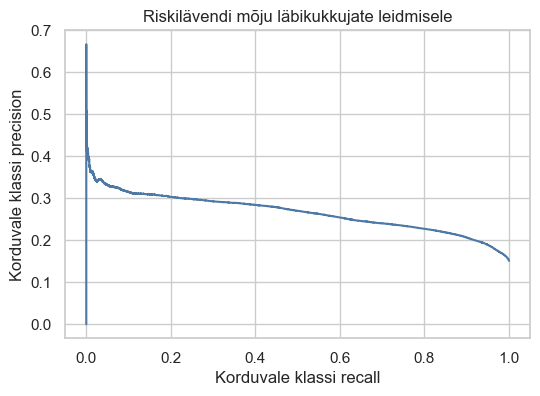

In [18]:
fail_true = 1 - y_test.to_numpy()
fail_score = 1 - y_prob
fail_precision, fail_recall, fail_thresholds = precision_recall_curve(fail_true, fail_score)

threshold_df = pd.DataFrame({
    "threshold": fail_thresholds,
    "fail_precision": fail_precision[:-1],
    "fail_recall": fail_recall[:-1],
})
threshold_df["fail_f1"] = (
    2 * threshold_df["fail_precision"] * threshold_df["fail_recall"]
    / (threshold_df["fail_precision"] + threshold_df["fail_recall"])
).fillna(0)

sorted_fail_scores = np.sort(fail_score)
risk_counts = len(sorted_fail_scores) - np.searchsorted(
    sorted_fail_scores, fail_thresholds, side="left"
)
threshold_df["predicted_risk_share"] = risk_counts / len(sorted_fail_scores)

summary_rows = []
for target_recall in [0.60, 0.70, 0.80, 0.90]:
    candidates = threshold_df[threshold_df["fail_recall"] >= target_recall]
    if not candidates.empty:
        best = candidates.sort_values(["fail_precision", "threshold"], ascending=False).iloc[0]
        summary_rows.append({
            "min_fail_recall": target_recall,
            "threshold": best["threshold"],
            "fail_precision": best["fail_precision"],
            "fail_recall": best["fail_recall"],
            "fail_f1": best["fail_f1"],
            "predicted_risk_share": best["predicted_risk_share"],
        })

threshold_summary = pd.DataFrame(summary_rows)
display(threshold_summary.round(3))

plt.figure(figsize=(6, 4))
plt.plot(threshold_df["fail_recall"], threshold_df["fail_precision"], color="#4e79a7")
plt.xlabel("Korduvale klassi recall")
plt.ylabel("Korduvale klassi precision")
plt.title("Riskilävendi mõju läbikukkujate leidmisele")
plt.show()


### Tõenäosuste kalibreerimise kontroll

Random Forest annab klassitõenäosusi, kuid need ei pruugi olla hästi kalibreeritud. Seetõttu kontrollime eraldi ajapõhist kalibreerimist: ajaliselt varasem aasta treenib baasmudeli, järgmise aasta peal õpib isotonic-kalibreerija ning 2025 jääb hindamiseks. See ei asenda lõppmudeli põhihindamist, vaid näitab, kas riskiskoori tõenäosuslik tõlgendus on usaldusväärne.

In [19]:
calibration_analysis = temporal_calibration_analysis(clean_df)

if calibration_analysis is not None:
    calibration_quality = pd.DataFrame([
        {
            "variant": "kalibreerimata",
            "brier_score": calibration_analysis["raw_probability_quality"]["brier_score"],
            "log_loss": calibration_analysis["raw_probability_quality"]["log_loss"],
            "expected_calibration_error": calibration_analysis["raw_probability_quality"]["expected_calibration_error"],
            "roc_auc": calibration_analysis["raw_roc_auc"],
        },
        {
            "variant": "isotonic",
            "brier_score": calibration_analysis["calibrated_probability_quality"]["brier_score"],
            "log_loss": calibration_analysis["calibrated_probability_quality"]["log_loss"],
            "expected_calibration_error": calibration_analysis["calibrated_probability_quality"]["expected_calibration_error"],
            "roc_auc": calibration_analysis["calibrated_roc_auc"],
        },
    ])
    display(calibration_quality.round(3))
else:
    print("Kalibreerimiskontrolliks on vaja v?hemalt kolme aastat andmeid.")


Ajaline kalibreerimine: treening=[2023], kalibreerimine=2024, test=2025
Kalibreerimise kvaliteet:
       variant  brier_score  log_loss  expected_calibration_error
kalibreerimata       0.2244    0.6365                      0.3199
      isotonic       0.1197    0.3871                      0.0065


,variant,brier_score,log_loss,expected_calibration_error,roc_auc
0,kalibreerimata,0.224,0.637,0.320,0.707
1,isotonic,0.120,0.387,0.007,0.707


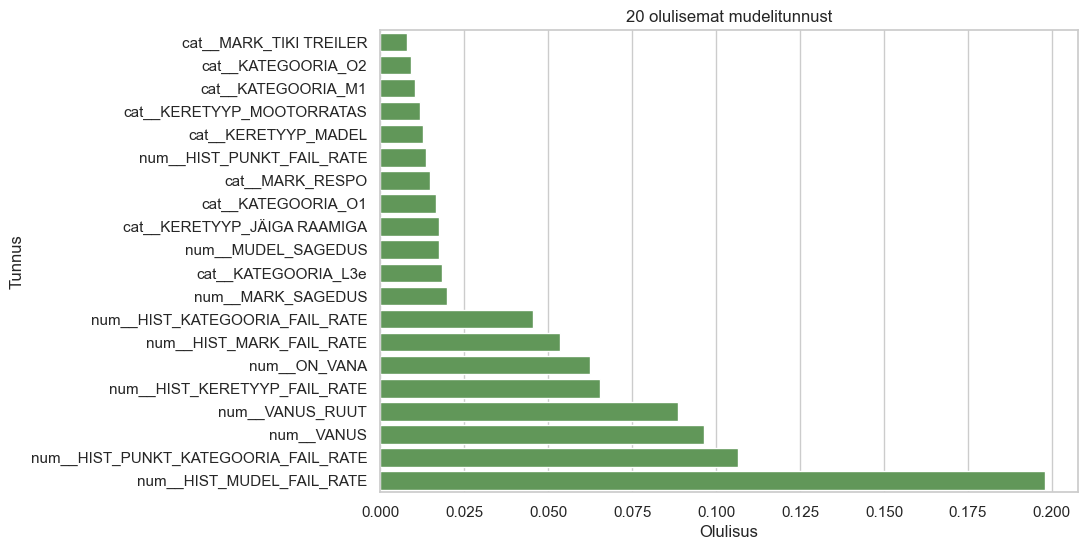

,feature,importance
9,num__HIST_MUDEL_FAIL_RATE,0.197839
13,num__HIST_PUNKT_KATEGOORIA_FAIL_RATE,0.106485
0,num__VANUS,0.096347
1,num__VANUS_RUUT,0.088679
11,num__HIST_KERETYYP_FAIL_RATE,0.065459
2,num__ON_VANA,0.062440
8,num__HIST_MARK_FAIL_RATE,0.053468
10,num__HIST_KATEGOORIA_FAIL_RATE,0.045493
5,num__MARK_SAGEDUS,0.019890
2754,cat__KATEGOORIA_L3e,0.018235


In [20]:
rf = model.named_steps["model"]
feature_names = model.named_steps["preprocess"].get_feature_names_out()
importance = (
    pd.DataFrame({"feature": feature_names, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance.sort_values("importance"), x="importance", y="feature", color="#59a14f")
plt.title("20 olulisemat mudelitunnust")
plt.xlabel("Olulisus")
plt.ylabel("Tunnus")
plt.show()

display(importance)

### Mudeli järeldus

Mudel treeniti 2023-2024 andmetel ja testiti 2025. aasta peal. See on ausam kui juhuslik split, sest mudel peab üldistuma tulevikuandmetele. Lihtne baseline, mis ennustaks kõigile `KORRAS`, annaks 2025 testis **84,9% accuracy**, kuid sellel puuduks võime läbikukkujaid eristada.

Parandatud Random Forest mudel kasutab lisaks tavalistele tunnustele treeningandmetelt õpitud ajaloolisi riskitunnuseid: margi, margi-mudeli, kategooria, keretüübi, ülevaatuspunkti ja punkti-kategooria ajalooline läbikukkumise määr. Need tunnused arvutatakse sklearn pipeline'i sees, seega 2025 testiaasta tulemused ei osale nende määrade arvutamises.

Parandatud mudeli tulemused olid: **accuracy 0,570**, **balanced accuracy 0,658**, **ROC AUC 0,710**, **precision 0,933**, **recall 0,532** ja **F1 0,678** klassi `Korras` jaoks.

Kui nõuda vähemalt **0,80** recall'i läbikukkujate leidmiseks, on sobiv riskilävi umbes **0,496**; sel juhul on precision **0,227** ja riskirühma satub **53,1%** 2025. aasta testiridadest. Kui nõuda vähemalt **0,90** recall'i, langeb precision **0,206** peale ja riskirühm kasvab **65,8%** peale.

Tugevaimad tunnused olid vanus, ajaloolised riskimäärad, sõidukikategooria/keretüüp, margi sagedus ja ülevaatuspunkti kood. See on kooskõlas esmase andme analüüsi tulemusega, kuid annab varasemast parema järjestusvõime.

### Streamlit'i dashboard

[LINK](https://andmeteaduskodutoo-avalik.streamlit.app/)

Parool: par00l_mis_vajab_sisestamist